In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f


Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/26 11:19:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/26 11:19:34 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [ ]:
path_to_release_folder = "../../../data/25.06/"

sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = path_to_release_folder + "output/evidence/sourceId=chembl"
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)

efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,
    efo_ids="MONDO_0045024",
)

chembl_evidence.show(1)

l2g_full = session.spark.read.parquet("../../../data/intermediate_files/l2g_full_for_enrichment/")
l2g_full.count()

l2g_full.show(1)

g_p_s = session.spark.read.parquet("../../../data/intermediate_files/genes_therapeutic_areas")
g_p_s.count()


25/11/26 11:21:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+----------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-----------------------

8285

25/11/26 12:58:05 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 899898 ms exceeds timeout 120000 ms
25/11/26 12:58:05 WARN SparkContext: Killing executors is not supported by current scheduler.
25/11/26 13:05:11 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

# Run


## All


In [39]:
import pandas as pd

all_enrich = []


In [40]:
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "full_l2g"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)


25/11/24 22:14:14 WARN CacheManager: Asked to cache already cached data.
25/11/24 22:14:15 WARN CacheManager: Asked to cache already cached data.


## OMIM


In [41]:
measurement_evidence = session.spark.read.parquet(
    "../../../data/intermediate_files/combined_evidence_with_measurements/"
)
measurement_evidence.groupBy("source").count().show()


+-----------------+------+
|           source| count|
+-----------------+------+
|     all_diseases| 36858|
|      gene_burden|  6857|
|             omim|  6596|
|         orphanet|  6192|
| all_measurements|150360|
|           ChEMBL| 25234|
|    cancer_ChEMBL|  8811|
|        gwas_eQTL| 12343|
|    gwas_with_pav|  5441|
|           molQTL| 17755|
|non_cancer_ChEMBL| 16423|
+-----------------+------+



In [42]:
evidence = measurement_evidence.filter(f.col("source") == "omim")


In [43]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "OMIM"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)


25/11/24 22:14:34 WARN CacheManager: Asked to cache already cached data.
25/11/24 22:14:35 WARN CacheManager: Asked to cache already cached data.        


## Gene-based


In [44]:
evidence = measurement_evidence.filter(f.col("source") == "gene_burden")


In [45]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Gene-based tests"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)


25/11/24 22:15:03 WARN CacheManager: Asked to cache already cached data.
25/11/24 22:15:04 WARN CacheManager: Asked to cache already cached data.        


## Orphanet


In [46]:
evidence = measurement_evidence.filter(f.col("source") == "orphanet")


In [47]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Orphanet"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)


25/11/24 22:15:30 WARN CacheManager: Asked to cache already cached data.
25/11/24 22:15:31 WARN CacheManager: Asked to cache already cached data.


In [ ]:
pd.concat(all_enrich, ignore_index=True)


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource
0,2+,1.746148,1.154068e-06,1.375083,2.217346,1.076425,1.050129,1.103380,5.340474e-09,6087,30548,76,666,151704,full_l2g,full_chembl
1,3+,2.060942,7.941172e-22,1.773924,2.394399,1.398926,1.321405,1.480995,8.135878e-31,20294,16341,279,463,151704,full_l2g,full_chembl
2,4+,3.618578,3.534571e-49,3.093638,4.232591,2.764540,2.483639,3.077211,3.161170e-77,32313,4322,500,242,151704,full_l2g,full_chembl
3,2+,1.166051,3.393830e-01,0.860342,1.580389,1.024072,0.979862,1.070278,2.907552e-01,6114,30925,49,289,60318,OMIM,full_chembl
4,3+,2.269655,2.110109e-13,1.813897,2.839927,1.447009,1.336564,1.566580,7.406482e-20,20454,16585,119,219,60318,OMIM,full_chembl
5,4+,5.343890,1.896568e-43,4.296015,6.647361,3.518942,3.095321,4.000540,2.276790e-82,32617,4422,196,142,60318,OMIM,full_chembl
6,2+,1.876780,2.981891e-01,0.669587,5.260409,1.083503,0.982134,1.195334,1.095344e-01,6159,31176,4,38,15304,Gene-based tests,full_chembl
7,3+,3.923301,6.242766e-05,1.928154,7.982914,1.696024,1.431679,2.009177,9.900233e-10,20563,16772,10,32,15304,Gene-based tests,full_chembl
8,4+,7.218138,2.586892e-09,3.939022,13.227017,4.109069,3.032952,5.567001,7.402276e-20,32792,4543,21,21,15304,Gene-based tests,full_chembl
9,2+,1.138623,4.438227e-01,0.831566,1.559061,1.020504,0.974111,1.069106,3.925392e-01,6117,30949,46,265,58015,Orphanet,full_chembl


# Spliting by categories


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from pyspark.sql import DataFrame
from statsmodels.stats.contrast import Contrast


def drug_enrichemnt_from_evidence_log_regression(
    evid: DataFrame,
    sub_evid: DataFrame,
    disease_index_orig: DataFrame,
    chembl_orig: DataFrame,
    suff: str,
    indirect_assoc_score_thr: float = 0.5,
    efo_ancestors_to_remove: list[str] | None = None,
) -> pd.DataFrame:
    """Run chembl drug enrichment from scores.

    Args:
        evid (DataFrame): Evidence table
        sub_evid (DataFrame): Subset of evidence table
        disease_index_orig (DataFrame): The original disease index (not epxloded)
        chembl_orig (DataFrame): Chembl evidence
        indirect_assoc_score_thr (float): Minimum score to keep in indirect associations
        efo_ancestors_to_remove (list[str] | None): List of EFO IDs to remove
    Returns:
        pd.DataFrame: Drug enrichment table.

    """
    if efo_ancestors_to_remove is not None:
        efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
            disease_index_orig=disease_index_orig,
            efo_ids=efo_ancestors_to_remove,
        )
    else:
        efo_to_remove = None

    chembl = chemblDrugEnrichment.process_chembl_evidence(chembl_orig, efo_to_remove)

    evid_indirect = chemblDrugEnrichment.evidence_to_indirect_assosiations(
        evid,
        disease_index_orig,
        use_max=True,
        efo_to_remove=efo_to_remove,
    ).cache()

    sub_evid_indirect = chemblDrugEnrichment.evidence_to_indirect_assosiations(
        sub_evid,
        disease_index_orig,
        use_max=True,
        efo_to_remove=efo_to_remove,
    ).cache()
    sub_evid_indirect = sub_evid_indirect.withColumn("subEvidence", f.lit(1))

    joined_data = evid_indirect.join(chembl, ["targetId", "diseaseId"], "right")
    joined_data = joined_data.join(
        sub_evid_indirect.select("targetId", "diseaseId", "subEvidence"), ["targetId", "diseaseId"], "left"
    ).toPandas()
    joined_data = joined_data.fillna({"indirect_assoc_score": 0, "subEvidence": 0})

    joined_data["outcome"] = (joined_data["maxClinicalPhase"] >= 4).astype(int)
    joined_data["geneticSupport"] = (joined_data["indirect_assoc_score"] >= indirect_assoc_score_thr).astype(int)
    joined_data["subEvidence"] = (joined_data["subEvidence"] >= indirect_assoc_score_thr).astype(int)

    joined_data["E"] = np.where(joined_data["geneticSupport"] == 0, 0, np.where(joined_data["subEvidence"] == 1, 2, 1))

    # ...existing code...
    joined_data["E"] = pd.Categorical(joined_data["E"], categories=[0, 1, 2], ordered=False)
    # rename_categories() returns the renamed categorical — assign it back
    joined_data["E"] = joined_data["E"].cat.rename_categories(["None", "GeneralOnly", "subEvidence"])
    # ...existing code...

    L1 = smf.logit("outcome ~ C(E)", data=joined_data).fit()

    contrast = np.array([0, 1, -1])
    ct = L1.t_test(contrast)
    pval_ct = ct.pvalue  # array or scalar

    coef = L1.params.iloc[1:3]
    pval = L1.pvalues.iloc[1:3]
    conf = L1.conf_int().iloc[1:3]
    conf.columns = ["CI_low", "CI_high"]

    results_df = pd.DataFrame(
        {
            "coef": coef,
            "OR": np.exp(coef),
            "pvalue": pval,
            "CI_low": np.exp(conf["CI_low"]),
            "CI_high": np.exp(conf["CI_high"]),
        }
    )

    labels = ["base", "subEvid"]
    results = []
    for label, (_, row) in zip(labels, results_df.iterrows()):
        results.append(
            {
                "clinicalPhase": "4+",
                "odds_ratio": float(row["OR"]),
                "p_value": float(row["pvalue"]),
                "ci_low": float(row["CI_low"]),
                "ci_high": float(row["CI_high"]),
                "Relative success": None,
                "ci_rs_low": None,
                "ci_rs_high": None,
                "rs_p_value": None,
                "no_evid-low_clinphase": None,
                "no_evid-high_clinphase": None,
                "yes_evid-low_clinphase": None,
                "yes_evid-high_clinphase": None,
                "total_indirect_assoc": evid_indirect.count(),
                "datasource": suff + "_" + label,
                "diffence_pval": pval_ct,
            }
        )
    return pd.DataFrame(results)


In [14]:
full_l2g_evidnce = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)
full_l2g_evidnce.count()


77071

In [ ]:
import pandas as pd

all_enrich_sub = []


In [ ]:
sub_l2g_evidnce = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds").filter(f.col("VEP") == 1),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)
sub_l2g_evidnce.count()


10275

In [ ]:
x = drug_enrichemnt_from_evidence_log_regression(
    evid=full_l2g_evidnce,
    sub_evid=sub_l2g_evidnce,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    suff="PAV",
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
x["drugsource"] = "full_chembl"
all_enrich_sub.append(x)


25/11/24 22:07:44 WARN CacheManager: Asked to cache already cached data.
25/11/24 22:07:53 WARN DAGScheduler: Broadcasting large task binary with size 1165.4 KiB


Optimization terminated successfully.
         Current function value: 0.368024
         Iterations 6


In [74]:
sub_l2g_evidnce = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds").filter(f.col("absBeta") > 0.5),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)
sub_l2g_evidnce.count()


3810

In [ ]:
x = drug_enrichemnt_from_evidence_log_regression(
    evid=full_l2g_evidnce,
    sub_evid=sub_l2g_evidnce,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    suff="BigEffect",
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
x["drugsource"] = "full_chembl"
all_enrich_sub.append(x)


25/11/24 22:08:03 WARN CacheManager: Asked to cache already cached data.
25/11/24 22:08:11 WARN DAGScheduler: Broadcasting large task binary with size 1165.3 KiB


Optimization terminated successfully.
         Current function value: 0.368179
         Iterations 6


In [ ]:
sub_l2g_evidnce = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds").filter(f.col("maf") < 0.01),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)
sub_l2g_evidnce.count()


1740

In [ ]:
x = drug_enrichemnt_from_evidence_log_regression(
    evid=full_l2g_evidnce,
    sub_evid=sub_l2g_evidnce,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    suff="rare",
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
x["drugsource"] = "full_chembl"
all_enrich_sub.append(x)


25/11/24 22:08:19 WARN CacheManager: Asked to cache already cached data.
25/11/24 22:08:24 WARN DAGScheduler: Broadcasting large task binary with size 1165.3 KiB


Optimization terminated successfully.
         Current function value: 0.368108
         Iterations 6


In [ ]:
gene_id_high_gps = g_p_s.filter(f.col("uniqueDiseases") >= 10).select("geneId").distinct()
gene_id_high_gps.count()


904

In [ ]:
sub_l2g_evidnce = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds").join(gene_id_high_gps, "geneId", "inner"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)
sub_l2g_evidnce.count()


41732

In [ ]:
x = drug_enrichemnt_from_evidence_log_regression(
    evid=full_l2g_evidnce,
    sub_evid=sub_l2g_evidnce,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    suff="high-gPS",
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
x["drugsource"] = "full_chembl"
all_enrich_sub.append(x)


25/11/24 22:08:34 WARN CacheManager: Asked to cache already cached data.
25/11/24 22:08:41 WARN DAGScheduler: Broadcasting large task binary with size 1175.0 KiB


Optimization terminated successfully.
         Current function value: 0.368123
         Iterations 6


# Combine all results


In [ ]:
# ...existing code...
def _flatten(lst):
    for it in lst:
        if isinstance(it, list):
            yield from _flatten(it)
        else:
            yield it


# combine both lists (all_enrich and all_enrich_sub)
items = list(_flatten(all_enrich)) + list(_flatten(all_enrich_sub))

# coerce acceptable types to DataFrame
processed = []
for it in items:
    if it is None:
        continue
    if isinstance(it, pd.DataFrame):
        processed.append(it)
    elif isinstance(it, dict):
        processed.append(pd.DataFrame([it]))
    else:
        # try general coercion (e.g. list-of-dicts, Series, etc.)
        try:
            df = pd.DataFrame(it)
            processed.append(df)
        except Exception as e:
            raise TypeError(f"Cannot coerce item of type {type(it)} to DataFrame: {e}")

# finally concatenate (outer join -> union of columns; missing fill with NaN)
if processed:
    all_enrich_df = pd.concat(processed, ignore_index=True, sort=False, join="outer")
else:
    all_enrich_df = pd.DataFrame()

print("combined rows:", len(all_enrich_df))
# ...existing code...


combined rows: 20


/var/folders/p5/4t9crp1563l792qz8xz_3x5h0000gq/T/ipykernel_89958/1811214158.py:31: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [ ]:
all_enrich_df


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource,diffence_pval
0,2+,1.746148,1.154068e-06,1.375083,2.217346,1.076425,1.050129,1.103380,5.340474e-09,6087,30548,76,666,151704,full_l2g,full_chembl,NaN
1,3+,2.060942,7.941172e-22,1.773924,2.394399,1.398926,1.321405,1.480995,8.135878e-31,20294,16341,279,463,151704,full_l2g,full_chembl,NaN
2,4+,3.618578,3.534571e-49,3.093638,4.232591,2.764540,2.483639,3.077211,3.161170e-77,32313,4322,500,242,151704,full_l2g,full_chembl,NaN
3,2+,1.166051,3.393830e-01,0.860342,1.580389,1.024072,0.979862,1.070278,2.907552e-01,6114,30925,49,289,60318,OMIM,full_chembl,NaN
4,3+,2.269655,2.110109e-13,1.813897,2.839927,1.447009,1.336564,1.566580,7.406482e-20,20454,16585,119,219,60318,OMIM,full_chembl,NaN
5,4+,5.343890,1.896568e-43,4.296015,6.647361,3.518942,3.095321,4.000540,2.276790e-82,32617,4422,196,142,60318,OMIM,full_chembl,NaN
6,2+,1.876780,2.981891e-01,0.669587,5.260409,1.083503,0.982134,1.195334,1.095344e-01,6159,31176,4,38,15304,Gene-based tests,full_chembl,NaN
7,3+,3.923301,6.242766e-05,1.928154,7.982914,1.696024,1.431679,2.009177,9.900233e-10,20563,16772,10,32,15304,Gene-based tests,full_chembl,NaN
8,4+,7.218138,2.586892e-09,3.939022,13.227017,4.109069,3.032952,5.567001,7.402276e-20,32792,4543,21,21,15304,Gene-based tests,full_chembl,NaN
9,2+,1.138623,4.438227e-01,0.831566,1.559061,1.020504,0.974111,1.069106,3.925392e-01,6117,30949,46,265,58015,Orphanet,full_chembl,NaN


In [69]:
# Filter and sort the DataFrame
combined_enrich_4 = all_enrich_df[all_enrich_df["clinicalPhase"] == "4+"]
combined_enrich_4 = combined_enrich_4[combined_enrich_4["drugsource"] != "Pharmaprojects"]
combined_enrich_4 = combined_enrich_4[combined_enrich_4["drugsource"] != "no_train_chembl"]
combined_enrich_4 = combined_enrich_4.iloc[::-1]
# combined_enrich_4 = combined_enrich_4.sort_values(by=["datasource", "drugsource", "odds_ratio"], ascending=[True, True, True])


In [70]:
combined_enrich_4


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource,diffence_pval
19,4+,2.967731,1.464477e-20,2.359467,3.732804,NaN,NaN,NaN,NaN,None,None,None,None,151704,high-gPS_subEvid,full_chembl,0.01628936386843402
18,4+,4.335055,7.507514e-42,3.506568,5.359287,NaN,NaN,NaN,NaN,None,None,None,None,151704,high-gPS_base,full_chembl,0.01628936386843402
17,4+,6.994051,5.723987e-14,4.211100,11.616146,NaN,NaN,NaN,NaN,None,None,None,None,151704,rare_subEvid,full_chembl,0.0077173575909135275
16,4+,3.395465,9.238817e-48,2.878920,4.004691,NaN,NaN,NaN,NaN,None,None,None,None,151704,rare_base,full_chembl,0.0077173575909135275
15,4+,4.628248,6.567012e-14,3.100539,6.908694,NaN,NaN,NaN,NaN,None,None,None,None,151704,BigEffect_subEvid,full_chembl,0.19331346982723208
14,4+,3.473019,5.278198e-47,2.931603,4.114424,NaN,NaN,NaN,NaN,None,None,None,None,151704,BigEffect_base,full_chembl,0.19331346982723208
13,4+,6.048323,1.378248e-29,4.425986,8.265325,NaN,NaN,NaN,NaN,None,None,None,None,151704,PAV_subEvid,full_chembl,0.0002440952882110829
12,4+,3.092428,3.530622e-34,2.579078,3.707957,NaN,NaN,NaN,NaN,None,None,None,None,151704,PAV_base,full_chembl,0.0002440952882110829
11,4+,5.007281,9.537626e-37,3.984204,6.293068,3.383752,2.949140,3.882413,1.176358e-67,32628,4438,185,126,58015,Orphanet,full_chembl,NaN
8,4+,7.218138,2.586892e-09,3.939022,13.227017,4.109069,3.032952,5.567001,7.402276e-20,32792,4543,21,21,15304,Gene-based tests,full_chembl,NaN


In [71]:
# Replace multiple values
combined_enrich_4["datasource"] = combined_enrich_4["datasource"].replace(
    {
        "PAV_base": "Without PAV",
        "PAV_subEvid": "With PAV",
        "rare_base": "Common Variants",
        "rare_subEvid": "Rare Variants",
        "high-gPS_base": "gPS<10",
        "high-gPS_subEvid": "gPS>=10",
        "full_l2g": "All genes",
        "Gene-based tests": "Gene-based",
        "BigEffect_base": "Small effect",
        "BigEffect_subEvid": "Large effect",
    }
)
combined_enrich_4 = combined_enrich_4[combined_enrich_4["datasource"] != "Not replicated CSs"]
combined_enrich_4 = combined_enrich_4[combined_enrich_4["datasource"] != "Replicated CSs"]


In [72]:
combined_enrich_4


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource,diffence_pval
19,4+,2.967731,1.464477e-20,2.359467,3.732804,NaN,NaN,NaN,NaN,None,None,None,None,151704,gPS>=10,full_chembl,0.01628936386843402
18,4+,4.335055,7.507514e-42,3.506568,5.359287,NaN,NaN,NaN,NaN,None,None,None,None,151704,gPS<10,full_chembl,0.01628936386843402
17,4+,6.994051,5.723987e-14,4.211100,11.616146,NaN,NaN,NaN,NaN,None,None,None,None,151704,Rare Variants,full_chembl,0.0077173575909135275
16,4+,3.395465,9.238817e-48,2.878920,4.004691,NaN,NaN,NaN,NaN,None,None,None,None,151704,Common Variants,full_chembl,0.0077173575909135275
15,4+,4.628248,6.567012e-14,3.100539,6.908694,NaN,NaN,NaN,NaN,None,None,None,None,151704,Large effect,full_chembl,0.19331346982723208
14,4+,3.473019,5.278198e-47,2.931603,4.114424,NaN,NaN,NaN,NaN,None,None,None,None,151704,Small effect,full_chembl,0.19331346982723208
13,4+,6.048323,1.378248e-29,4.425986,8.265325,NaN,NaN,NaN,NaN,None,None,None,None,151704,With PAV,full_chembl,0.0002440952882110829
12,4+,3.092428,3.530622e-34,2.579078,3.707957,NaN,NaN,NaN,NaN,None,None,None,None,151704,Without PAV,full_chembl,0.0002440952882110829
11,4+,5.007281,9.537626e-37,3.984204,6.293068,3.383752,2.949140,3.882413,1.176358e-67,32628,4438,185,126,58015,Orphanet,full_chembl,NaN
8,4+,7.218138,2.586892e-09,3.939022,13.227017,4.109069,3.032952,5.567001,7.402276e-20,32792,4543,21,21,15304,Gene-based,full_chembl,NaN


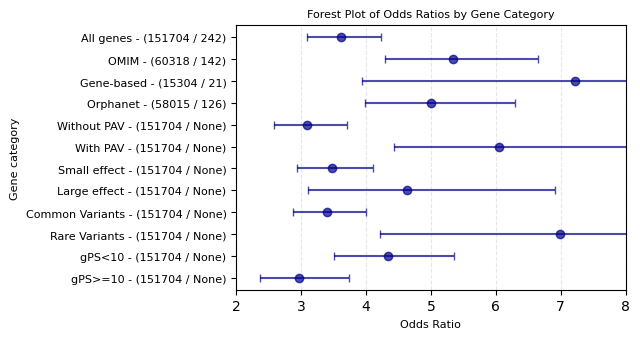

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique datasources and drugsources
# combined_enrich_4 = combined_enrich_4.sort_values(by="odds_ratio", ascending=True)
unique_datasources = combined_enrich_4["datasource"].unique()
unique_drugsources = combined_enrich_4["drugsource"].unique()
colors = ["darkblue", "green"]  # Two different colors for the two drugsources

# Create the plot
plt.figure(figsize=(6.5, 3.5))

# Create y-positions for each datasource group
y_positions = []
y_labels = []
y_pos = 0

for datasource in unique_datasources:
    datasource_data = combined_enrich_4[combined_enrich_4["datasource"] == datasource]

    for i, drugsource in enumerate(unique_drugsources):
        drugsource_data = datasource_data[datasource_data["drugsource"] == drugsource]

        if not drugsource_data.empty:
            for _, row in drugsource_data.iterrows():
                odds_ratio = row["odds_ratio"]
                ci_low = row["ci_low"]
                ci_high = row["ci_high"]

                # Plot the point with error bars
                plt.errorbar(
                    odds_ratio,
                    y_pos,
                    xerr=[[odds_ratio - ci_low], [ci_high - odds_ratio]],
                    fmt="o",
                    color=colors[i],
                    ecolor=colors[i],
                    capsize=3,
                    alpha=0.7,
                    label=drugsource if datasource == unique_datasources[0] else "",
                )

                # Create label
                label = f"{datasource} - ({row['total_indirect_assoc']} / {row['yes_evid-high_clinphase']})"
                y_labels.append(label)
                y_positions.append(y_pos)
                y_pos += 1

    # Add some spacing between datasource groups
    y_pos += 0.5

# Customize the plot
# plt.axvline(x=1, color='black', linestyle='--', alpha=0.5, label="Null Effect (OR=1)")
plt.xlabel("Odds Ratio", fontsize=8)
plt.ylabel("Gene category", fontsize=8)
plt.title("Forest Plot of Odds Ratios by Gene Category", fontsize=8)

# Set y-tick labels
plt.yticks(y_positions, y_labels, fontsize=8)
# plt.legend(loc='upper right')
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.xlim(2, 8)
plt.xticks([2, 3, 4, 5, 6, 7, 8])

# Adjust layout and show
plt.tight_layout()
plt.show()


In [ ]:
0.05 / 4


0.0125

In [76]:
# example only
import numpy as np
from statsmodels.stats.multitest import multipletests

p = np.array([0.0002440952882110829, 0.19331346982723208, 0.0077173575909135275, 0.01628936386843402])

rej, p_adj, _, _ = multipletests(p, alpha=0.05, method="fdr_bh")
print("original p:", p)
print("adjusted p:", p_adj)
print("reject H0 at FDR 0.05:", rej)


original p: [0.0002441  0.19331347 0.00771736 0.01628936]
adjusted p: [0.00097638 0.19331347 0.01543472 0.02171915]
reject H0 at FDR 0.05: [ True False  True  True]
